In [2]:
import pandas as pd

In [5]:
df=pd.read_csv("C:/Users/ramya/Downloads/Retail_Sales_Raw (1).csv")

In [7]:
print(df.head())

   OrderID   OrderDate   CustomerName Region ProductCategory     Product  \
0     1001  06-23-2025       Sara Ali  SOUTH     Electronics      Laptop   
1     1002  05-10-2025     Aisha Khan   West     Electronics  Headphones   
2     1003  26-02-2025  Arjun Nambiar  South     Electronics  Headphones   
3     1004  25-02-2025  Arjun Nambiar  South      Stationery    Notebook   
4     1005  09-03-2025    Rohan Mehta   West     Electronics      Laptop   

   Quantity  UnitPrice  Discount  
0         2     115.49      0.00  
1         1      51.38      0.05  
2        -2     352.16      0.15  
3         4     173.42      0.05  
4         3     424.51       NaN  


In [9]:
print(df.shape)

(125, 9)


In [12]:
df.describe()

,OrderID,Quantity,UnitPrice,Discount
count,125.000000,125.000000,125.000000,96.000000
mean,1061.336000,2.344000,252.284720,0.085417
std,34.641702,2.129304,137.774894,0.052273
min,1001.000000,-2.000000,5.840000,0.000000
25%,1032.000000,1.000000,147.670000,0.050000
50%,1061.000000,3.000000,241.960000,0.100000
75%,1091.000000,4.000000,358.200000,0.150000
max,1120.000000,5.000000,486.080000,0.150000


In [14]:
df.dtypes

OrderID              int64
OrderDate           object
CustomerName        object
Region              object
ProductCategory     object
Product             object
Quantity             int64
UnitPrice          float64
Discount           float64
dtype: object

In [16]:
df = df.drop_duplicates()
df["Discount"] = df["Discount"].fillna(0)

In [20]:
high_price = df[df["UnitPrice"] > 450] # Filter high price products
print(high_price) 

     OrderID   OrderDate   CustomerName Region ProductCategory     Product  \
16      1017  10-05-2025  Arjun Nambiar  SOUTH        Clothing     T-Shirt   
30      1031  15-03-2025     Neha Gupta  North       Furniture     Cabinet   
31      1032  07-08-2025       Sara Ali  South        Clothing      Jacket   
39      1040  09-03-2025    Divya Menon   East     Electronics  Headphones   
49      1050  03-31-2025       Sara Ali   East       Furniture     Cabinet   
53      1054  03-22-2025    Rohan Mehta   West       Furniture   Bookshelf   
75      1076  29-06-2025    Rohan Mehta  SOUTH       Furniture     Cabinet   
80      1081  01-07-2025    Rohan Mehta   West     Electronics     Monitor   
95      1096  05-03-2025            NaN  South     Electronics       Mouse   
96      1097  31-05-2025     Neha Gupta  north        Clothing      Jacket   
97      1098  10-06-2025  Arjun Nambiar  north      Stationery    Notebook   
110     1111  28-06-2025     Anjali Rao   East     Electronics  

In [35]:
laptops = df[
    (df["ProductCategory"] == "Electronics") &
    (df["Product"] == "Laptop")
]                                      # Filter electronics laptops

print(laptops)                         # Display laptop records

     OrderID   OrderDate   CustomerName Region ProductCategory Product  \
0       1001  06-23-2025       Sara Ali  SOUTH     Electronics  Laptop   
4       1005  09-03-2025    Rohan Mehta   West     Electronics  Laptop   
13      1014  02-06-2025     Priya Nair  North     Electronics  Laptop   
23      1024  26-03-2025    Divya Menon  SOUTH     Electronics  Laptop   
29      1030  13-04-2025     Priya Nair  South     Electronics  Laptop   
43      1044  05-30-2025  Arjun Nambiar  North     Electronics  Laptop   
71      1072  13-01-2025     Neha Gupta  SOUTH     Electronics  Laptop   
74      1075  09-02-2025     Karan Shah  North     Electronics  Laptop   
93      1094  17-02-2025       Sara Ali  north     Electronics  Laptop   
104     1105  07-15-2025    Divya Menon  South     Electronics  Laptop   
111     1112  22-05-2025  Imran Qureshi  SOUTH     Electronics  Laptop   

     Quantity  UnitPrice  Discount  
0           2     115.49      0.00  
4           3     424.51      0.00  


In [38]:
sorted_df = df.sort_values(
    by="UnitPrice",
    ascending=False
)                                      # Sort prices descending

print(sorted_df.head(10))  

     OrderID   OrderDate   CustomerName Region ProductCategory     Product  \
16      1017  10-05-2025  Arjun Nambiar  SOUTH        Clothing     T-Shirt   
31      1032  07-08-2025       Sara Ali  South        Clothing      Jacket   
49      1050  03-31-2025       Sara Ali   East       Furniture     Cabinet   
80      1081  01-07-2025    Rohan Mehta   West     Electronics     Monitor   
95      1096  05-03-2025            NaN  South     Electronics       Mouse   
75      1076  29-06-2025    Rohan Mehta  SOUTH       Furniture     Cabinet   
97      1098  10-06-2025  Arjun Nambiar  north      Stationery    Notebook   
112     1113  05-08-2025    Rohan Mehta  South        Clothing     T-Shirt   
39      1040  09-03-2025    Divya Menon   East     Electronics  Headphones   
110     1111  28-06-2025     Anjali Rao   East     Electronics       Mouse   

     Quantity  UnitPrice  Discount  
16          3     486.08      0.05  
31          2     484.51      0.00  
49          1     483.61      

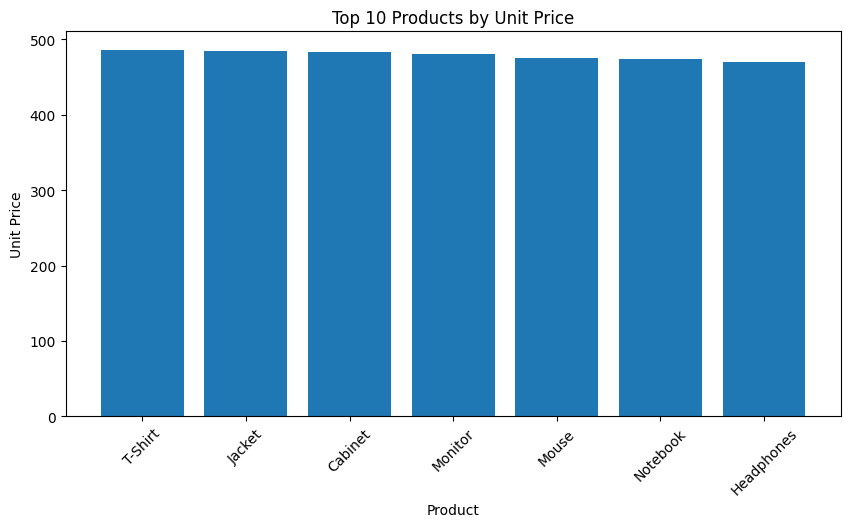

In [40]:
import matplotlib.pyplot as plt        # Import plotting library
plt.figure(figsize=(10,5))             # Set chart size
plt.bar(
    sorted_df["Product"].head(10),
    sorted_df["UnitPrice"].head(10)
)                                      # Create bar chart top prices
plt.title("Top 10 Products by Unit Price") # Add chart title
plt.xlabel("Product")                  # Label x axis
plt.ylabel("Unit Price")               # Label y axis
plt.xticks(rotation=45)                # Rotate product labels
plt.show()

In [42]:
print("Mean =", df["UnitPrice"].mean()) # Calculate average price

print("Median =", df["UnitPrice"].median()) # Calculate middle price

print("Mode =", df["UnitPrice"].mode()) # Find common price

print(
    "Standard Deviation =",
    df["UnitPrice"].std()
)

Mean = 254.98158333333333
Median = 246.38
Mode = 0        5.84
1        7.92
2        9.61
3       26.61
4       27.88
        ...  
115    474.82
116    480.59
117    483.61
118    484.51
119    486.08
Name: UnitPrice, Length: 120, dtype: float64
Standard Deviation = 135.88936654311402


In [44]:
category_avg = df.groupby(
    "ProductCategory"
)["UnitPrice"].mean()                  # Calculate category average

print(category_avg)                    # Display category averages

ProductCategory
Clothing       249.121034
Electronics    275.980357
Furniture      261.564687
Stationery     234.701935
Name: UnitPrice, dtype: float64


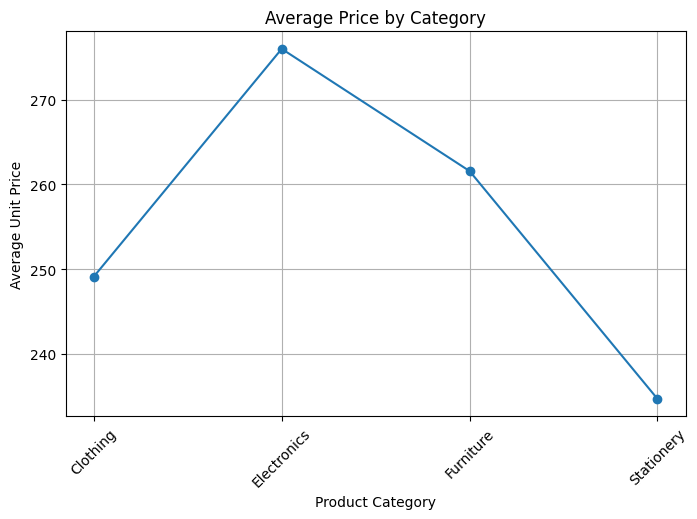

In [46]:
# Create line chart prices
plt.figure(figsize=(8,5))              
plt.plot(
    category_avg.index,
    category_avg.values,
    marker="o"
)                                      
plt.title("Average Price by Category") 
plt.xlabel("Product Category")         
plt.ylabel("Average Unit Price")       
plt.xticks(rotation=45)                
plt.grid(True)                         
plt.show()         

Region
East     17
North    53
SOUTH    56
South    76
West     48
north    31
Name: Quantity, dtype: int64


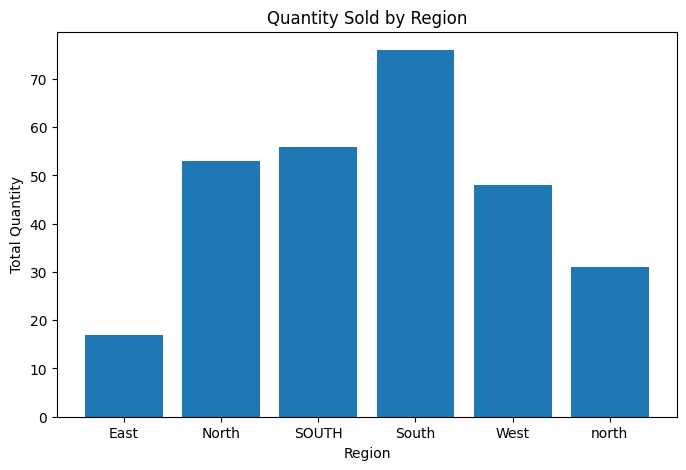

In [48]:
region_sales = df.groupby(
    "Region"
)["Quantity"].sum()                    # Calculate quantity by region

print(region_sales)                    # Display regional quantities


plt.figure(figsize=(8,5))              # Set chart size

plt.bar(
    region_sales.index,
    region_sales.values
)                                      # Create bar chart by region

plt.title("Quantity Sold by Region")   # Add chart title

plt.xlabel("Region")                   # Label x axis

plt.ylabel("Total Quantity")           # Label y axis

plt.show()                             # Display region chart


In [49]:
corr = df[
    ["Quantity", "UnitPrice", "Discount"]
].corr()                                # Calculate numerical correlation

print(corr)                            # Display correlation results

           Quantity  UnitPrice  Discount
Quantity   1.000000  -0.003791  -0.06432
UnitPrice -0.003791   1.000000  -0.06560
Discount  -0.064320  -0.065600   1.00000
